# Neural-network training stage: test on 2019
Reads `TEST_TRAIN/train.csv` without downloading or rewriting data.
Elections through 2017 form the training input; 2019 is held out for testing.
All model and preprocessing code is included here; no project modules are imported.

This shifts the pipeline's **final retraining** procedure back one election, skipping the
initial comparison of model families. The full training dataset through 2017 is
supplied, but each of ten networks uses half of 2017 for early stopping and the
other half plus all earlier elections for weight updates. There is no subsequent
fit on all rows. Each seed gets its own split and fitted preprocessor.

Each network prints **epochs run** (including patience epochs) and the **best epoch**
whose weights are restored. Training uses the configured seeds, architecture, SGD,
and early-stopping settings, with cross-entropy loss for training and validation. The 2019 test data is used only after fitting.


In [1]:
from pathlib import Path
from typing import Any, TypedDict
import copy
import warnings
import numpy as np
from numpy.typing import NDArray
import pandas as pd
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

project_root = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "TEST_TRAIN" / "train.csv").is_file()), None,
)
if project_root is None:
    raise FileNotFoundError("Run this notebook from inside the election project.")
data = pd.read_csv(project_root / "TEST_TRAIN" / "train.csv")
data_years = pd.to_numeric(data["election"], errors="raise")
if data_years.isna().any():
    raise ValueError("Election years must not be missing.")
train = data.loc[data_years <= 2017].copy()
test = data.loc[data_years == 2019].copy()
FEATURE_COLUMNS = [
    "country/region",
    "previous_majority_proportion",
    "previous_winner",
    "Conservative",
    "Labour",
    "LD",
    "incumbent",
    "previous_con_share",
    "previous_lib_share",
    "previous_lab_share",
    "previous_natSW_share",
    "projected_con_share",
    "projected_lib_share",
    "projected_lab_share",
]
CATEGORICAL_COLUMNS = ["country/region", "previous_winner", "incumbent"]
NUMERIC_COLUMNS = [
    column for column in FEATURE_COLUMNS if column not in CATEGORICAL_COLUMNS
]
SEEDS = tuple(range(101223, 101233))
BATCH_SIZE = 64
MAX_EPOCHS = 1000
PATIENCE = 50
MIN_DELTA = 0.001
LEARNING_RATE = 0.01
HIDDEN_SIZES = (32, 16)

# Small CPU networks avoid unnecessary thread overhead.
torch.set_num_threads(1)
years = pd.to_numeric(train["election"], errors="raise")
if years.isna().any() or (years > 2017).any() or not (years == 2017).any():
    raise ValueError("Expected training elections through 2017, with no later rows.")
if train.empty or train["winner"].isna().any():
    raise ValueError("Training requires nonempty data with known winners.")
evaluation_years = pd.to_numeric(test["election"], errors="raise")
evaluation_data = test.loc[evaluation_years == 2019].dropna(subset=["winner"]).copy()
if evaluation_data.empty:
    raise ValueError("No labelled 2019 test rows.")
print(f"Training input: {len(train)} rows through 2017")
print(f"2019 evaluation: {len(evaluation_data)} labelled rows")


Training input: 5073 rows through 2017
2019 evaluation: 632 labelled rows


In [2]:
def make_preprocessor() -> ColumnTransformer:
    """Create preprocessing to fit on training rows and reuse for prediction."""
    return ColumnTransformer([
        # Fill missing numbers with training medians, then centre and scale them.
        # Keep even entirely missing columns so the feature layout stays stable.
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
        ]), NUMERIC_COLUMNS),
        ("categorical", Pipeline([
            # Treat missing categories as a named category. One-hot encoding makes
            # a separate indicator column for each category seen during fitting;
            # unseen categories at prediction time get all-zero indicators.
            ("impute", SimpleImputer(
                strategy="constant", fill_value="__MISSING__", keep_empty_features=True
            )),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_COLUMNS),
    ])

def as_features(matrix: NDArray[Any] | sparse.spmatrix) -> torch.Tensor:
    """Convert sklearn's feature matrix into a dense float32 PyTorch tensor."""
    # One-hot encoding can produce sparse matrices; these linear layers need dense input.
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    array = np.asarray(matrix, dtype=np.float32)
    # Fail early if preprocessing leaves NaN or infinite values in the predictors.
    if not np.isfinite(array).all():
        raise ValueError("Preprocessed predictors contain non-finite values.")
    return torch.from_numpy(array)

class NeuralNetwork(nn.Module):
    """CPU classifier trained with cross-entropy on raw logits."""

    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        layers = []
        # Each linear layer learns weighted combinations of its inputs. ReLU sets
        # negative outputs to zero, letting the network learn nonlinear patterns.
        for width in HIDDEN_SIZES:
            layers.extend([nn.Linear(input_dim, width), nn.ReLU()])
            input_dim = width
        # Output raw logits for cross-entropy, which applies log-softmax internally.
        # Convert logits to probabilities with softmax only for evaluation.
        layers.append(nn.Linear(input_dim, num_classes))
        self.layers = nn.Sequential(*layers)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # Calling network(X) passes the rows through every layer in sequence.
        return self.layers(X)

class TrainingRecord(TypedDict):
    """Diagnostics for one seeded training run."""

    seed: int
    best_epoch: int | None
    stopping_epoch: int
    best_validation_loss: float | None

def _train_network(
    training: pd.DataFrame, validation: pd.DataFrame | None,
    label_encoder: LabelEncoder, seed: int, epochs: int,
) -> tuple[NeuralNetwork, ColumnTransformer, TrainingRecord]:
    """Restore the best checkpoint with validation; otherwise run exactly epochs."""
    preprocessor = make_preprocessor()
    # Learn preprocessing only from training rows to avoid leaking validation data.
    x_train = as_features(preprocessor.fit_transform(training[FEATURE_COLUMNS]))
    # Cross-entropy expects integer class indices and raw network logits.
    y_train = torch.tensor(
        label_encoder.transform(training["winner"]), dtype=torch.long,
    )
    if validation is not None:
        x_validation = as_features(preprocessor.transform(validation[FEATURE_COLUMNS]))
        y_validation = torch.tensor(
            label_encoder.transform(validation["winner"]), dtype=torch.long,
        )

    # Keep initialisation reproducible without changing the caller's RNG state.
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(seed)
        network = NeuralNetwork(x_train.shape[1], len(label_encoder.classes_))
        # Shuffle paired features and labels into batches with a separately seeded
        # generator, making the batch order reproducible for this run.
        loader = DataLoader(
            TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True,
            generator=torch.Generator().manual_seed(seed), num_workers=0,
        )
        optimizer = torch.optim.SGD(network.parameters(), lr=LEARNING_RATE, momentum=0.0)
        # Average negative log probability of the winning class over rows.
        criterion = nn.CrossEntropyLoss()
        best_loss = float("inf")
        best_epoch = 0
        best_state = None
        stale_epochs = 0
        for epoch in range(1, epochs + 1):
            network.train()
            for x_batch, y_batch in loader:
                # Clear old gradients, measure this batch's error, differentiate
                # it with respect to the weights, then apply an SGD update.
                optimizer.zero_grad()
                loss = criterion(network(x_batch), y_batch)
                if not torch.isfinite(loss).item():
                    raise RuntimeError(f"Non-finite training loss for seed {seed}, epoch {epoch}")
                loss.backward()
                optimizer.step()
            if validation is None:
                # Refitting uses a fixed duration, with no early-stopping check.
                continue
            # Evaluate held-out rows after each epoch without updating the weights.
            network.eval()
            with torch.inference_mode():
                validation_loss = criterion(
                    network(x_validation), y_validation
                ).item()
            if not np.isfinite(validation_loss):
                raise RuntimeError(f"Non-finite validation loss for seed {seed}, epoch {epoch}")
            if best_loss - validation_loss >= MIN_DELTA:
                best_loss = validation_loss
                best_epoch = epoch
                # Copy the weights so later updates cannot change this checkpoint.
                best_state = copy.deepcopy(network.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1
            if stale_epochs >= PATIENCE:
                break
        if validation is not None:
            # Use the best qualifying checkpoint, which can precede the stopping epoch.
            network.load_state_dict(best_state)
        network.eval()
    # Keep diagnostics for inspecting duration selection and subsequent refits.
    record: TrainingRecord = {"seed": seed, "best_epoch": best_epoch if validation is not None else None,
              "stopping_epoch": epoch,
              "best_validation_loss": best_loss if validation is not None else None}
    return network, preprocessor, record


In [3]:
label_encoder = LabelEncoder().fit(train["winner"])
latest = train.loc[years == years.max()]
historical = train.loc[years < years.max()]
if historical.empty or len(latest) < 2:
    raise ValueError("Need historical elections and at least two latest-election rows.")
counts = latest["winner"].value_counts()
can_stratify = counts.min() >= 2 and len(latest) // 2 >= len(counts)
if not can_stratify:
    warnings.warn("Latest-election class counts do not permit stratification.")

networks, preprocessors, records = [], [], []
for index, seed in enumerate(SEEDS, start=1):
    latest_train, validation = train_test_split(
        latest, test_size=0.5, random_state=seed,
        stratify=latest["winner"] if can_stratify else None,
    )
    training = pd.concat([historical, latest_train])
    network, preprocessor, record = _train_network(
        training, validation, label_encoder, seed, MAX_EPOCHS,
    )
    networks.append(network)
    preprocessors.append(preprocessor)
    records.append(record)
    print(
        f"Network {index}/{len(SEEDS)} | seed {seed} | "
        f"epochs run: {record['stopping_epoch']} | "
        f"best epoch (restored): {record['best_epoch']} | "
        f"best validation cross-entropy: {record['best_validation_loss']:.6f} | "
        f"training rows: {len(training)}, validation rows: {len(validation)}",
        flush=True,
    )
training_records = pd.DataFrame(records)
display(training_records)


Network 1/10 | seed 101223 | epochs run: 78 | best epoch (restored): 28 | best validation cross-entropy: 0.263681 | training rows: 4757, validation rows: 316
Network 2/10 | seed 101224 | epochs run: 72 | best epoch (restored): 22 | best validation cross-entropy: 0.303197 | training rows: 4757, validation rows: 316
Network 3/10 | seed 101225 | epochs run: 383 | best epoch (restored): 333 | best validation cross-entropy: 0.240703 | training rows: 4757, validation rows: 316
Network 4/10 | seed 101226 | epochs run: 404 | best epoch (restored): 354 | best validation cross-entropy: 0.255446 | training rows: 4757, validation rows: 316
Network 5/10 | seed 101227 | epochs run: 85 | best epoch (restored): 35 | best validation cross-entropy: 0.325089 | training rows: 4757, validation rows: 316
Network 6/10 | seed 101228 | epochs run: 93 | best epoch (restored): 43 | best validation cross-entropy: 0.289884 | training rows: 4757, validation rows: 316
Network 7/10 | seed 101229 | epochs run: 83 | be

,seed,best_epoch,stopping_epoch,best_validation_loss
0,101223,28,78,0.263681
1,101224,22,72,0.303197
2,101225,333,383,0.240703
3,101226,354,404,0.255446
4,101227,35,85,0.325089
5,101228,43,93,0.289884
6,101229,33,83,0.296467
7,101230,44,94,0.265827
8,101231,29,79,0.271951
9,101232,434,484,0.257525


## Evaluate the trained ensemble on 2019
The complete-row score matches the pipeline notebook's evaluation filter.
The additional all-labelled-row score includes seats with missing predictors,
using each network's fitted imputer. Neither score affects training or selection.


Pipeline-equivalent 2019 accuracy: 88.08% (629 complete rows)
Excluded 3 labelled rows with missing predictors.
All-labelled-row 2019 accuracy: 87.97% (632 rows)


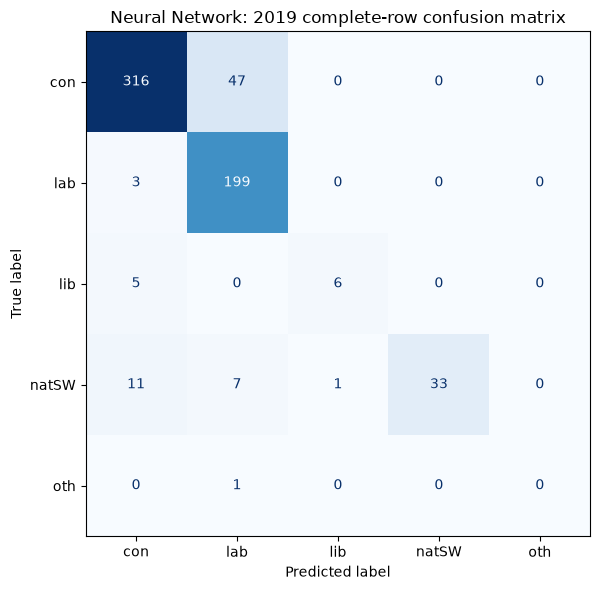

In [4]:
if len(networks) != len(SEEDS):
    raise ValueError("Train all ten networks before evaluation.")
probabilities_by_model = []
with torch.inference_mode():
    for network, preprocessor in zip(networks, preprocessors):
        features = as_features(preprocessor.transform(evaluation_data[FEATURE_COLUMNS]))
        network.eval()
        probabilities_by_model.append(torch.softmax(network(features), dim=1).numpy())
ensemble_probabilities = np.mean(probabilities_by_model, axis=0)
ensemble_predictions = label_encoder.inverse_transform(ensemble_probabilities.argmax(axis=1))
complete = evaluation_data[FEATURE_COLUMNS].notna().all(axis=1).to_numpy()
if not complete.any():
    raise ValueError("No complete 2019 rows for pipeline-equivalent evaluation.")
complete_accuracy = accuracy_score(evaluation_data.loc[complete, "winner"], ensemble_predictions[complete])
all_accuracy = accuracy_score(evaluation_data["winner"], ensemble_predictions)
print(f"Pipeline-equivalent 2019 accuracy: {complete_accuracy:.2%} ({complete.sum()} complete rows)")
print(f"Excluded {len(evaluation_data) - complete.sum()} labelled rows with missing predictors.")
print(f"All-labelled-row 2019 accuracy: {all_accuracy:.2%} ({len(evaluation_data)} rows)")
party_labels = sorted(set(evaluation_data.loc[complete, "winner"]) | set(ensemble_predictions[complete]))
matrix = confusion_matrix(evaluation_data.loc[complete, "winner"], ensemble_predictions[complete], labels=party_labels)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(matrix, display_labels=party_labels).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Neural Network: 2019 complete-row confusion matrix")
fig.tight_layout()
plt.show()


## Accuracy on seats that changed party in 2019
A seat changed party when its recorded `winner` differs from `previous_winner`.
Rows without a known previous winner are excluded. Report both complete-row and
all-labelled-row accuracy using the ensemble predictions already computed above.


In [5]:
changed = (
    evaluation_data["previous_winner"].notna()
    & evaluation_data["previous_winner"].ne(evaluation_data["winner"])
).to_numpy()
changed_seat_accuracies = {}
for label, mask in [
    ("Complete-row", changed & complete),
    ("All-labelled-row", changed),
]:
    count = int(mask.sum())
    if count:
        accuracy = accuracy_score(
            evaluation_data.loc[mask, "winner"], ensemble_predictions[mask]
        )
        changed_seat_accuracies[label] = accuracy
        print(f"{label} 2019 changed-seat accuracy: {accuracy:.2%} ({count} seats)")
    else:
        changed_seat_accuracies[label] = None
        print(f"{label} 2019 changed-seat accuracy: N/A (0 seats)")


Complete-row 2019 changed-seat accuracy: 12.00% (75 seats)
All-labelled-row 2019 changed-seat accuracy: 13.16% (76 seats)


## Brier score and log loss (cross-entropy)
The multiclass Brier score is the mean, across seats, of the sum over all parties
of squared differences between predicted probabilities and one-hot outcomes.
This uses the unscaled multiclass convention (range 0–2).
Log loss and cross-entropy are the same metric here: the mean negative natural
logarithm of the actual winner's probability. Lower is better for both metrics.
An unseen winning party receives probability zero; log loss clips probabilities
to float64 machine epsilon to avoid infinite values. Metrics use the same
2019 evaluation subsets as the accuracy results above.


In [6]:
import numpy as np


def probability_scores(winners, probabilities, classes):
    """Mean multiclass Brier score and cross-entropy, with natural logarithms."""
    # Include unseen winning parties with predicted probability zero.
    labels = list(classes)
    labels += [label for label in pd.unique(np.asarray(winners)) if label not in labels]
    probability_table = pd.DataFrame(
        np.asarray(probabilities, dtype=float), columns=classes
    ).reindex(columns=labels, fill_value=0.0)
    probabilities = probability_table.to_numpy()
    winner_columns = pd.Index(labels).get_indexer(np.asarray(winners))
    targets = np.eye(len(labels))[winner_columns]
    brier = float(np.mean(np.sum((probabilities - targets) ** 2, axis=1)))
    winning_probabilities = probabilities[np.arange(len(winner_columns)), winner_columns]
    # Clip zero probabilities to keep log loss finite, including unseen winners.
    log_loss = float(-np.mean(np.log(np.clip(
        winning_probabilities, np.finfo(float).eps, 1.0
    ))))
    return {"brier_score": brier, "log_loss_cross_entropy": log_loss}

# Score the ensemble's mean probabilities in label-encoder class order.
probability_metrics = {}
for label, mask in [
    ("Complete-row", complete),
    ("All-labelled-row", np.ones(len(evaluation_data), dtype=bool)),
]:
    scores = probability_scores(
        evaluation_data.loc[mask, "winner"],
        ensemble_probabilities[mask],
        label_encoder.classes_,
    )
    probability_metrics[label] = scores
    print(f"{label} 2019 probability metrics ({int(mask.sum())} seats):")
    print(f"  Brier score: {scores['brier_score']:.6f}")
    print(f"  Log loss (cross-entropy): {scores['log_loss_cross_entropy']:.6f}")


Complete-row 2019 probability metrics (629 seats):
  Brier score: 0.180785
  Log loss (cross-entropy): 0.305368
All-labelled-row 2019 probability metrics (632 seats):
  Brier score: 0.182231
  Log loss (cross-entropy): 0.309914
